# **Step 0 — Setup**


In [1]:
import time                      # to time the Hessian construction in Part 3
import torch                     # tensor library + autograd
import torch.nn as nn            # ready-made layers (used for the tiny MLPs)
import matplotlib.pyplot as plt  # for the plots in the exercises

# Make results repeatable — same reason as in Practical 4.
torch.manual_seed(0)

# Print tensors with 4 decimals and no scientific notation, so outputs are easy to read.
torch.set_printoptions(precision=4, sci_mode=False)

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu128


## Checkpoint

### Q1. What does `create_graph=True` do, and what happens without it?
It keeps the computation graph of the gradient itself, so the gradient is a differentiable tensor. Without it the returned gradient is detached from the graph and a second `autograd.grad` call raises an error. This flag is the whole difference between a first-order and a second-order method in PyTorch.

### Q2. Why call `torch.manual_seed(0)`?
Fixes the random number generator so results are repeatable and a change in output can be traced to your edit, not to luck.

# **Part 1 — Gradient, Hessian and the Newton Step**

**Aim:** reproduce the worked example by computing **g** and **H** with autograd instead of by hand.

The second-order Taylor expansion of the loss around the current parameters is

$$L(w+\Delta w) \approx L(w) + g^\top \Delta w + \tfrac12 \Delta w^\top H\, \Delta w$$

Setting the derivative with respect to Δw to zero gives the Newton system and its solution:

$$H\,\Delta w = -g \quad\Rightarrow\quad \Delta w = -H^{-1} g \qquad\qquad w_{new} = w - H^{-1} g$$

Apply it to $L(w) = w^2 - 4w + 5$ from $w_0 = 5$. Expected by hand: g = 6, H = 2, and the first step lands exactly on w = 2.

In [2]:
# The loss: a simple quadratic bowl with its minimum at w = 2.
def L(w):
    return w**2 - 4*w + 5

# Start at w0 = 5 and tell autograd to track derivatives with respect to w.
w = torch.tensor(5.0, requires_grad=True)

# First derivative g. create_graph=True keeps the graph alive so g can be differentiated again.
g = torch.autograd.grad(L(w), w, create_graph=True)[0]

# Second derivative H: differentiate the gradient with respect to w.
H = torch.autograd.grad(g, w)[0]

# Newton step: w_new = w - g/H  (in one dimension H^-1 is just 1/H).
w_new = w - g / H

print(f"w0 = {w.item():.4f}   g = {g.item():.4f}   H = {H.item():.4f}")
print(f"w1 = w0 - g/H = {w_new.item():.4f}")
print(f"L(w0) = {L(w).item():.4f}   ->   L(w1) = {L(w_new).item():.4f}")

w0 = 5.0000   g = 6.0000   H = 2.0000
w1 = w0 - g/H = 2.0000
L(w0) = 10.0000   ->   L(w1) = 1.0000


**Result:** matches the hand calculation — g = 6, H = 2, w₁ = 2, and the loss falls from 10 to 1 (the exact minimum) in **one** iteration. For a quadratic objective the second-order Taylor expansion is not an approximation, it *is* the function, so the Newton step jumps straight to the vertex.

## Tasks

### Exercise 1 — Newton on L(w) = 3w² − 12w + 7 from w = 4
Report g, H and w₁, and confirm by hand that the method reaches the optimum in one step.

In [3]:
def L_ex1(w):
    return 3*w**2 - 12*w + 7

w = torch.tensor(4.0, requires_grad=True)
g = torch.autograd.grad(L_ex1(w), w, create_graph=True)[0]   # first derivative
H = torch.autograd.grad(g, w)[0]                             # second derivative
w_new = w - g / H                                            # Newton step

print(f"g = {g.item():.4f}   H = {H.item():.4f}   w1 = {w_new.item():.4f}")
print(f"L(w0) = {L_ex1(w).item():.4f}   ->   L(w1) = {L_ex1(w_new).item():.4f}")

g = 12.0000   H = 6.0000   w1 = 2.0000
L(w0) = 7.0000   ->   L(w1) = -5.0000


**Result:** g = 12, H = 6, w₁ = 2, and the loss goes 7 → −5.

**By hand:** L′(w) = 6w − 12 → L′(4) = 12; L″(w) = 6. Δw = −g/H = −12/6 = −2, so w₁ = 4 − 2 = **2**. Check: L′(2) = 0 and L″ = 6 > 0, so w = 2 is the minimum, and L(2) = 12 − 24 + 7 = −5 ✅. One step, because the loss is quadratic.

### Exercise 3 — What goes wrong on L(w) = w⁴ − 3w² + w from w = 0.1?
Replace the loss with the quartic, run Newton's method, and explain the failure using the sign of H.

In [4]:
import numpy as np   # only used to list the true stationary points for reference

def L_quartic(w):
    return w**4 - 3*w**2 + w

w = torch.tensor(0.1, requires_grad=True)
for i in range(6):
    g = torch.autograd.grad(L_quartic(w), w, create_graph=True)[0]   # slope
    H = torch.autograd.grad(g, w)[0]                                 # curvature
    print(f"iter {i}: w = {w.item():.6f}   L = {L_quartic(w).item():.6f}   g = {g.item():+.6f}   H = {H.item():+.6f}")
    w = (w - g / H).detach().requires_grad_(True)                    # Newton step, then restart the graph

# All stationary points (g = 0) of the quartic:  4w^3 - 6w + 1 = 0
print()
for r in sorted(np.roots([4, 0, -6, 1]).real):
    kind = "minimum" if 12*r**2 - 6 > 0 else "MAXIMUM"
    print(f"stationary point w = {r:+.4f}   L = {r**4 - 3*r**2 + r:+.4f}   H = {12*r**2 - 6:+.4f}   -> {kind}")

iter 0: w = 0.100000   L = 0.070100   g = +0.404000   H = -5.880000
iter 1: w = 0.168707   L = 0.084131   g = +0.006962   H = -5.658453
iter 2: w = 0.169938   L = 0.084135   g = +0.000003   H = -5.653453
iter 3: w = 0.169938   L = 0.084135   g = -0.000000   H = -5.653451
iter 4: w = 0.169938   L = 0.084135   g = -0.000000   H = -5.653451
iter 5: w = 0.169938   L = 0.084135   g = -0.000000   H = -5.653451

stationary point w = -1.3008   L = -3.5139   H = +14.3062   -> minimum
stationary point w = +0.1699   L = +0.0841   H = -5.6535   -> MAXIMUM
stationary point w = +1.1309   L = -1.0702   H = +9.3472   -> minimum


**Result:** at w = 0.1 the curvature is **H = −5.88 < 0**, so the loss surface is concave there. The Newton step (+0.0687) moves *uphill*: L rises from 0.0701 to 0.0841, and by iteration 2 it has converged to **w = 0.1699**, where H = −5.65 — a local **maximum**. The true minima are at w = 1.1309 (L = −1.0702) and w = −1.3008 (L = −3.5139); Newton never went near them.

**Why:** Newton's method solves g = 0 — it finds *any* stationary point. The step −g/H is a descent direction only when H > 0. When H < 0 the sign flips and the method is attracted to maxima (or saddles in higher dimensions). Fixes: damp the Hessian (H + λI with λ > |H|, as in Levenberg–Marquardt, Part 4), use a trust region, or fall back to a gradient step whenever H is not positive definite.

## Checkpoint

### Q1. Derive the Newton update.
Differentiate the second-order Taylor expansion L(w) + gᵀΔw + ½ΔwᵀHΔw with respect to Δw and set it to zero: HΔw = −g, so Δw = −H⁻¹g.

### Q2. Why does Newton converge in one step on a quadratic?
The Taylor expansion of a quadratic has no higher-order terms — it is exact — so the step lands on the vertex. In this lab: L = w² − 4w + 5, w₀ = 5 → w₁ = 2 in one step (Exercise 1: same, 4 → 2).

### Q3. Does Newton need a learning rate?
No. Solving HΔw = −g fixes both direction and length. In 1-D the step length is g/H, i.e. the slope scaled by the inverse curvature.

### Q4. What breaks when H < 0?
The step −g/H points *uphill*; Newton converges to a maximum or saddle. Exercise 3: from w = 0.1, H = −5.88, the method converged to the local maximum at w = 0.1699.

### Q5. Why `torch.linalg.solve(H, g)` instead of `H.inverse() @ g`?
Solving the linear system is cheaper and numerically more stable than forming H⁻¹ explicitly.

# **Part 2 — Newton versus Gradient Descent on a Stretched Valley**

**Aim:** see what curvature information buys you when the loss surface is badly conditioned.

The bowl below is **20× steeper** in one direction than the other. Gradient descent must use a step size small enough for the steep direction (stability needs lr < 2/λ_max = 0.1), which makes it crawl along the shallow one. `torch.autograd.functional.hessian` builds H for us.

In [5]:
from torch.autograd.functional import hessian   # returns the full n x n Hessian matrix

A = torch.tensor([[20.0, 0.0], [0.0, 1.0]])     # curvature: 20 along axis 1, 1 along axis 2
b = torch.tensor([2.0, 1.0])

def loss(w):
    return 0.5 * w @ A @ w - b @ w              # quadratic bowl; gradient = A w - b, Hessian = A

w_star = torch.linalg.solve(A, b)               # the exact optimum, for measuring error
print("optimum   :", w_star)

# ---------- Gradient descent, 60 iterations ----------
w = torch.tensor([3.0, -4.0], requires_grad=True)
for i in range(1, 61):
    gr = torch.autograd.grad(loss(w), w)[0]
    with torch.no_grad():
        w -= 0.09 * gr                          # largest stable step is 2/20 = 0.1
    if i in (1, 10, 30, 60):
        print(f"GD iter {i:3d}  error = {(w - w_star).norm().item():.6f}")

# ---------- Newton, ONE step ----------
w = torch.tensor([3.0, -4.0], requires_grad=True)
gr = torch.autograd.grad(loss(w), w)[0]         # gradient at the start point
Hm = hessian(loss, w)                           # full Hessian
w_newton = w.detach() - torch.linalg.solve(Hm, gr)
print("Hessian   :", Hm.tolist())
print(f"Newton 1 step error = {(w_newton - w_star).norm().item():.6e}")

optimum   : tensor([0.1000, 1.0000])
GD iter   1  error = 5.107338
GD iter  10  error = 1.971822
GD iter  30  error = 0.295287
GD iter  60  error = 0.017436
Hessian   : [[20.0, 0.0], [0.0, 1.0]]
Newton 1 step error = 9.685755e-08


**Result:** matches the tutorial exactly. After 60 gradient steps the error is still 1.7 × 10⁻²; **one** Newton step reaches 9.7 × 10⁻⁸ (float32 round-off). No learning rate was chosen for Newton — solving HΔw = −g sets the step length too. Raise the GD step above 0.1 and it diverges: 2/λ_max is the stability limit.

## Tasks

### Exercise 2 — Change A to [[20, 0], [0, 0.05]]
How many gradient-descent iterations are needed to match one Newton step, and how does that relate to the condition number of A?

Counting to error ≈ 10⁻⁷ is at the edge of float32 precision (the optimum coordinate 20.0 cannot be stored more accurately than ≈ 2 × 10⁻⁶), so the counting loop below runs in **float64**. The Newton step is shown in float32 as in the tutorial.

In [6]:
def newton_error(Amat):
    """One Newton step from (3, -4) in float32 - returns the error against the exact optimum."""
    bb = torch.tensor([2.0, 1.0])
    f = lambda w: 0.5 * w @ Amat @ w - bb @ w
    w = torch.tensor([3.0, -4.0], requires_grad=True)
    gr = torch.autograd.grad(f(w), w)[0]
    step = torch.linalg.solve(hessian(f, w), gr)
    return ((w.detach() - step) - torch.linalg.solve(Amat, bb)).norm().item()

def gd_iterations(Amat, lr=0.09, targets=(1e-3, 1e-6, 1e-7)):
    """Plain gradient descent in float64. Returns {target error: first iteration that reaches it}."""
    Ad = Amat.double()
    bd = torch.tensor([2.0, 1.0], dtype=torch.float64)
    ws = torch.linalg.solve(Ad, bd)                       # exact optimum
    w = torch.tensor([3.0, -4.0], dtype=torch.float64)
    hits = {}
    for i in range(1, 200001):
        w = w - lr * (Ad @ w - bd)                        # gradient of the quadratic is A w - b
        err = (w - ws).norm().item()
        for t in targets:
            if t not in hits and err <= t:
                hits[t] = i
        if len(hits) == len(targets):
            break
    return hits

for name, Am in [("kappa = 20  (A = diag(20, 1))   ", torch.tensor([[20.0, 0.0], [0.0, 1.0]])),
                 ("kappa = 400 (A = diag(20, 0.05))", torch.tensor([[20.0, 0.0], [0.0, 0.05]]))]:
    print(name, "| Newton 1-step error (float32): %.2e" % newton_error(Am))
    print("   GD iterations to reach error <= 1e-3 / 1e-6 / 1e-7:", list(gd_iterations(Am).values()))

kappa = 20  (A = diag(20, 1))    | Newton 1-step error (float32): 9.69e-08
   GD iterations to reach error <= 1e-3 / 1e-6 / 1e-7: [91, 164, 188]
kappa = 400 (A = diag(20, 0.05)) | Newton 1-step error (float32): 9.69e-08
   GD iterations to reach error <= 1e-3 / 1e-6 / 1e-7: [2237, 3768, 4279]


**Result:**

| A | κ = λ_max/λ_min | Newton, 1 step | GD iters to 1e-3 | to 1e-6 | to 1e-7 (≈ Newton) |
|---|---|---|---|---|---|
| diag(20, 1) | 20 | 9.7e-8 | 91 | 164 | 188 |
| diag(20, 0.05) | 400 | 9.7e-8 | 2,237 | 3,768 | 4,279 |

Newton is unaffected — still one step. Gradient descent now needs **≈ 23× more iterations** (4,279 vs 188 to reach Newton's accuracy), which tracks the **20× increase in condition number** (20 → 400).

**Why:** the stability limit fixes lr ≤ 2/λ_max = 0.1 whatever λ_min is. Along the shallow direction each step only shrinks the error by (1 − lr·λ_min), so the number of iterations to reach accuracy ε is ≈ ln(e₀/ε) / (lr·λ_min) ∝ **κ · ln(1/ε)**. (The ratio is slightly above 20 because the start point is also farther from the optimum along the shallow axis: e₀ ≈ 24 vs 5.) Newton multiplies by H⁻¹, which rescales every direction to equal curvature, so its step count does not depend on κ for a quadratic.

## Checkpoint

### Q1. What limits the gradient-descent step size?
Stability: lr < 2/λ_max. Here λ_max = 20, so lr < 0.1; the lab used 0.09.

### Q2. Why does GD crawl along the shallow direction?
The lr is capped by the steep direction, but the error along the shallow direction shrinks only by (1 − lr·λ_min) per step: 0.91 for λ_min = 1 (κ = 20), 0.9955 for λ_min = 0.05 (κ = 400).

### Q3. How does the condition number κ affect GD and Newton?
GD needs ≈ κ·ln(1/ε) iterations (Exercise 2: 188 → 4,279 for κ 20 → 400). Newton on a quadratic needs one step regardless of κ.

### Q4. Why is Newton's error 9.7e-8 and not exactly 0?
float32 round-off; mathematically the step lands exactly on the optimum.

### Q5. What does `hessian(loss, w)` return?
The full n × n matrix of second derivatives — here the 2 × 2 matrix [[20, 0], [0, 1]].

# **Part 3 — What the Hessian Actually Costs**

**Aim:** turn the O(n²) memory and O(n³) inversion claims into measured numbers.

Build the full Hessian of a tiny MLP for four different widths and record time and storage. `torch.func.functional_call` lets us treat the network as a plain function of **one flat parameter vector**, which is what `hessian()` needs.

In [7]:
from torch.func import functional_call            # call a module with a dict of parameters we supply

def hessian_cost(hidden):
    torch.manual_seed(0)
    net = nn.Sequential(nn.Linear(4, hidden), nn.Tanh(), nn.Linear(hidden, 1))
    names = [n for n, _ in net.named_parameters()]                 # e.g. '0.weight', '0.bias', ...
    flat = torch.cat([p.reshape(-1) for p in net.parameters()])    # all parameters as ONE vector
    x, y = torch.randn(16, 4), torch.randn(16, 1)                  # a tiny random regression batch

    def flat_loss(v):
        # Slice the flat vector back into the per-layer tensors, then evaluate the network.
        params, i = {}, 0
        for n, p in zip(names, net.parameters()):
            params[n] = v[i:i + p.numel()].view_as(p)
            i += p.numel()
        return ((functional_call(net, params, (x,)) - y) ** 2).mean()

    t0 = time.time()
    Hm = hessian(flat_loss, flat)                                  # the full n x n Hessian
    dt = time.time() - t0
    return flat.numel(), dt, Hm.numel() * 4 / 1024**2              # (n, seconds, megabytes at 4 bytes/float)

hessian_cost(4)                                                    # warm-up run, result discarded
print(f"{'params n':>9}{'Hessian time (s)':>19}{'Hessian memory (MB)':>22}")
for hidden in (8, 32, 128, 512):
    n, dt, mb = hessian_cost(hidden)
    print(f"{n:9d}{dt:19.3f}{mb:22.2f}")

n = 10_000_000                                                     # a small real network
print(f"extrapolated to n = {n:,}: {n**2 * 4 / 1024**4:,.0f} TB")

 params n   Hessian time (s)   Hessian memory (MB)
       49              0.039                  0.01
      193              0.193                  0.14
      769              0.753                  2.26
     3073              2.767                 36.02
extrapolated to n = 10,000,000: 364 TB


**Result:** memory matches the tutorial exactly (0.01 → 0.14 → 2.26 → 36.02 MB); times are machine-dependent and noisy at small n, but at n = 3,073 the build takes roughly 1–3 s depending on the machine (tutorial: 1.06 s; 2.8 s in the run saved here). Every 4× increase in n multiplies storage by ≈ 16× — the O(n²) growth, visible in four rows. At n = 3,073 the Hessian already takes about a second and 36 MB, for a network with one hidden layer and four inputs. For n = 10⁷ it would need **364 TB** before even attempting the O(n³) inversion. Everything in the rest of the lab exists to avoid this table.

## Checkpoint

### Q1. How does Hessian memory grow with n? Show it from the table.
O(n²): n² entries × 4 bytes. n = 769 → 3,073 is 4× more parameters and memory goes 2.26 → 36.02 MB, ≈ 16×.

### Q2. What is the cost of *inverting* (or solving with) H?
O(n³) time. A 4× larger n means ≈ 64× more work for the solve, on top of building H.

### Q3. Why does the lab use `functional_call` and a flat vector?
`hessian()` differentiates a function of a *single tensor*. Flattening all parameters into one vector and slicing them back inside `flat_loss` makes the network such a function.

### Q4. What would n = 10,000,000 need?
n² × 4 bytes ≈ **364 TB** just to store H.

# **Part 4 — Gauss–Newton and Levenberg–Marquardt**

**Aim:** implement the damped least-squares update and watch λ interpolate between Gauss–Newton and gradient descent.

When the loss is a sum of squared residuals, the Hessian can be approximated from the Jacobian J of the residuals alone:

$$H \approx J^\top J$$

Adding a damping term λI gives the Levenberg–Marquardt update, which stays well-behaved even when JᵀJ is nearly singular:

$$\Delta w = -(J^\top J + \lambda I)^{-1} J^\top e$$

We fit θ₀·exp(θ₁·x) to noisy samples of 3·exp(−1.5x) from a poor start. Only λ changes between the three runs.

In [8]:
from torch.autograd.functional import jacobian   # Jacobian of a vector-valued function

torch.manual_seed(1)                             # so this Part stands alone
x = torch.linspace(0, 2, 40)                     # 40 sample points
y = 3.0 * torch.exp(-1.5 * x) + 0.02 * torch.randn(40)   # noisy data from theta = (3, -1.5)

def residual(theta):                             # e = model - data, a vector of 40 residuals
    return theta[0] * torch.exp(theta[1] * x) - y

def lm(lmbda, iters=10):
    theta = torch.tensor([1.0, -0.2])            # deliberately poor starting guess
    for _ in range(iters):
        r = residual(theta)
        J = jacobian(residual, theta)            # 40 x 2
        JtJ = J.T @ J                            # Gauss-Newton Hessian approximation
        step = torch.linalg.solve(JtJ + lmbda * torch.eye(2), J.T @ r)   # damped Newton system
        theta = theta - step
    return theta, (residual(theta) ** 2).sum().item()

print(f"{'method':<22}{'SSE after 3':>14}{'SSE after 10':>14}   theta after 10")
for lmbda, name in [(0.0, "Gauss-Newton (lam=0)"),
                    (1.0, "LM  (lam=1)"),
                    (1000.0, "LM  (lam=1000)")]:
    _, sse3 = lm(lmbda, iters=3)
    th, sse10 = lm(lmbda, iters=10)
    print(f"{name:<22}{sse3:14.5f}{sse10:14.5f}   [{th[0]:.4f}, {th[1]:.4f}]")
print(f"{'true theta':<22}{'':>28}[3.0000, -1.5000]")

method                   SSE after 3  SSE after 10   theta after 10
Gauss-Newton (lam=0)         0.01275       0.01275   [2.9702, -1.4856]
LM  (lam=1)                  0.02001       0.01275   [2.9702, -1.4856]
LM  (lam=1000)              19.82258      18.62383   [1.0708, -0.2604]
true theta                                        [3.0000, -1.5000]


**Result:** matches the tutorial. Undamped Gauss–Newton has converged after **3** iterations (SSE 0.01275). Mild damping (λ = 1) costs early progress (SSE 0.02001 after 3) and catches up by iteration 10. Heavy damping (λ = 1000) shrinks the update to ≈ (1/λ)·Jᵀe — plain gradient descent with η = 1/λ — and after 10 iterations SSE is still 18.62, θ = [1.07, −0.26], barely off the start.

## Tasks

### Exercise 4 — Adaptive Levenberg–Marquardt
Multiply λ by 10 when a step increases the SSE (reject it) and divide λ by 10 when the step succeeds (accept it). Report the λ trajectory over ten iterations.

In [9]:
import math

def adaptive_lm(theta0, lmbda0, iters=10):
    theta = torch.tensor(theta0)
    lmbda = lmbda0
    sse = (residual(theta) ** 2).sum().item()
    used = []                                              # the lambda actually used at each iteration
    for k in range(1, iters + 1):
        r = residual(theta)
        J = jacobian(residual, theta)
        step = torch.linalg.solve(J.T @ J + lmbda * torch.eye(2), J.T @ r)
        cand = theta - step                                # trial point
        sse_c = (residual(cand) ** 2).sum().item()         # trial SSE
        used.append(lmbda)
        if math.isfinite(sse_c) and sse_c <= sse:          # SSE did not increase -> success
            theta, sse, verdict = cand, sse_c, "accepted"
            new_lmbda = lmbda / 10                         # trust the quadratic model more -> smaller lambda
        else:                                              # SSE increased -> failure, discard the step
            verdict = "REJECTED"
            new_lmbda = lmbda * 10                         # trust it less -> more damping (more like GD)
        print(f"iter {k:2d}  lam = {lmbda:9.3g}  {verdict:<8}  trial SSE = {sse_c:12.5g}  kept SSE = {sse:.5f}")
        lmbda = new_lmbda
    return theta, used

print("Run A - tutorial start theta0 = [1.0, -0.2], lam0 = 1")
th, lam_A = adaptive_lm([1.0, -0.2], 1.0)
print("lambda trajectory:", [f"{l:g}" for l in lam_A], "\n")

print("Run B - hard start theta0 = [0.1, 1.0] (exponent has the wrong sign), lam0 = 1e-3")
th, lam_B = adaptive_lm([0.1, 1.0], 1e-3)
print("lambda trajectory:", [f"{l:g}" for l in lam_B])

Run A - tutorial start theta0 = [1.0, -0.2], lam0 = 1
iter  1  lam =         1  accepted  trial SSE =       3.3337  kept SSE = 3.33368
iter  2  lam =       0.1  accepted  trial SSE =     0.034247  kept SSE = 0.03425
iter  3  lam =      0.01  accepted  trial SSE =     0.012756  kept SSE = 0.01276
iter  4  lam =     0.001  accepted  trial SSE =     0.012754  kept SSE = 0.01275
iter  5  lam =    0.0001  REJECTED  trial SSE =     0.012754  kept SSE = 0.01275
iter  6  lam =     0.001  REJECTED  trial SSE =     0.012754  kept SSE = 0.01275
iter  7  lam =      0.01  REJECTED  trial SSE =     0.012754  kept SSE = 0.01275
iter  8  lam =       0.1  REJECTED  trial SSE =     0.012754  kept SSE = 0.01275
iter  9  lam =         1  REJECTED  trial SSE =     0.012754  kept SSE = 0.01275
iter 10  lam =        10  REJECTED  trial SSE =     0.012754  kept SSE = 0.01275
lambda trajectory: ['1', '0.1', '0.01', '0.001', '0.0001', '0.001', '0.01', '0.1', '1', '10'] 

Run B - hard start theta0 = [0.1, 1.0] (

**Result:**

**Run A (tutorial start, λ₀ = 1)** — λ used at iterations 1–10: `1, 0.1, 0.01, 0.001, 1e-4, 1e-3, 0.01, 0.1, 1, 10`.
The first four steps all succeed, so λ falls 10× each time while SSE drops 3.334 → 0.0343 → 0.01276 → 0.01275: the method shifts from gradient-descent-like to pure Gauss–Newton as it approaches the solution. From iteration 5 the SSE has stopped moving (0.01275 is the least-squares minimum for this data), so float32 noise makes every trial SSE a hair *larger*, the steps are "rejected" and λ climbs again. That climb is not a bug in the rule — it is what the rule does at convergence, which is why real implementations add a stopping test on the step size or SSE change.

**Run B (hard start, λ₀ = 10⁻³)** — λ used: `1e-3, 1e-4, 1e-3, 0.01, 0.1, 1, 0.1, 1, 0.1, 0.01`.
This shows the mechanism working. Iteration 1 is accepted, but at λ = 10⁻⁴ the almost-undamped step overshoots catastrophically (trial SSE ≈ 7.7 × 10²⁶) and is rejected; λ is raised ×10 each time (10⁻³ → 10⁻² → 0.1) through trial SSEs of 9.2 × 10²⁵, 9.5 × 10¹⁸ and 575, until λ = 1 finally gives a step that lowers the loss (SSE 14.02). It then oscillates around λ ≈ 0.1–1 while SSE falls 14.02 → 2.97 → 0.22 → 0.0136. Safety of gradient descent when the model is untrustworthy, speed of Gauss–Newton when it is.

## Checkpoint

### Q1. What approximation does Gauss–Newton make?
H ≈ JᵀJ — it drops the term Σ rᵢ∇²rᵢ (residual × second derivative of the residual). Accurate when residuals are small or the model is nearly linear. It needs only first derivatives.

### Q2. What does λ do in (JᵀJ + λI)Δw = −Jᵀe?
λ → 0: Gauss–Newton (fast, can overshoot). λ → ∞: Δw ≈ −(1/λ)Jᵀe, i.e. gradient descent with lr = 1/λ (slow, safe). Lab: λ = 1000 gave SSE 18.62 after 10 iterations vs 0.01275 for λ = 0.

### Q3. Why does damping help numerically?
JᵀJ + λI is symmetric positive definite for any λ > 0, so it is always invertible, even when JᵀJ is nearly singular.

### Q4. State the adaptive LM rule.
Step lowers SSE → accept it and divide λ by 10. Step raises SSE → reject it and multiply λ by 10. (Exercise 4.)

### Q5. Why is Gauss–Newton restricted to least-squares problems?
The JᵀJ shortcut relies on the loss being a sum of squared residuals; for a general loss there is no such Jacobian-only approximation of H.

# **Part 5 — L-BFGS: Quasi-Newton in One Line**

**Aim:** use the quasi-Newton method through `torch.optim` and compare its iteration count against Adam.

L-BFGS never forms H. It rebuilds an implicit inverse-Hessian from the last few gradient differences, so memory is a small multiple of n rather than n². In PyTorch it needs a **closure**, because one step may evaluate the loss several times during its line search.

In [10]:
def fit(make_opt, steps):
    torch.manual_seed(0)
    theta = torch.tensor([1.0, -0.2], requires_grad=True)
    opt = make_opt([theta])

    def closure():                                   # L-BFGS may call this many times per step
        opt.zero_grad()
        loss = (residual(theta) ** 2).sum()
        loss.backward()
        return loss

    for _ in range(steps):
        opt.step(closure)
    return theta.detach(), (residual(theta) ** 2).sum().item()

for steps in (10, 50, 200, 500):
    _, sse = fit(lambda p: torch.optim.Adam(p, lr=0.05), steps)
    print(f"Adam    {steps:4d} steps   SSE = {sse:.5f}")

for steps in (1, 2, 5):
    th, sse = fit(lambda p: torch.optim.LBFGS(p, lr=0.5, max_iter=20), steps)
    print(f"L-BFGS  {steps:4d} steps   SSE = {sse:.5f}")

Adam      10 steps   SSE = 9.88366
Adam      50 steps   SSE = 0.07337
Adam     200 steps   SSE = 0.01275
Adam     500 steps   SSE = 0.01275
L-BFGS     1 steps   SSE = 0.01275
L-BFGS     2 steps   SSE = 0.01275
L-BFGS     5 steps   SSE = 0.01275


**Result:** matches the tutorial. Adam is still at SSE 0.07337 after 50 steps and has reached 0.01275 by 200; L-BFGS reaches it in a **single** `opt.step()`. Read that honestly: `max_iter=20` means one outer step performs up to 20 inner iterations, each with its own closure evaluations — so the fair claim is "curvature information is worth far more per gradient evaluation here", not "L-BFGS is 20× cheaper". L-BFGS also assumes a *deterministic* loss; with mini-batches the curvature estimates come from inconsistent gradients — the main reason it is rare in deep learning (tested in Exercise 5).

## Tasks

### Exercise 5 — Small MLP instead of the exponential: L-BFGS vs Adam, full-batch vs mini-batch
Fit the same 40 data points with a 1 → 16 → 1 tanh MLP. For each optimizer run full-batch (batch = 40) and mini-batch (batch = 8), and record the **full-data** MSE plus the number of closure (loss + gradient) evaluations, since L-BFGS makes many per step.

In [11]:
xs, ys = x.unsqueeze(1), y.unsqueeze(1)              # data from Part 4 as (40, 1) column tensors

def make_mlp():
    torch.manual_seed(0)                             # identical initial weights for every run
    return nn.Sequential(nn.Linear(1, 16), nn.Tanh(), nn.Linear(16, 1))

def full_mse(net):                                   # always evaluate on ALL 40 points
    with torch.no_grad():
        return ((net(xs) - ys) ** 2).mean().item()

def run(opt_name, batch, epochs):
    net = make_mlp()
    if opt_name == "Adam":
        opt = torch.optim.Adam(net.parameters(), lr=0.01)
    else:
        opt = torch.optim.LBFGS(net.parameters(), lr=1.0, max_iter=20,
                                history_size=10, line_search_fn="strong_wolfe")
    gen = torch.Generator().manual_seed(0)           # same mini-batch order for both optimizers
    evals = 0
    for epoch in range(epochs):
        perm = torch.randperm(40, generator=gen)     # reshuffle each epoch
        for s in range(0, 40, batch):
            idx = perm[s:s + batch]
            xb, yb = xs[idx], ys[idx]                # the current (mini-)batch
            def closure():
                nonlocal evals
                evals += 1
                opt.zero_grad()
                loss = ((net(xb) - yb) ** 2).mean()
                loss.backward()
                return loss
            opt.step(closure)
    return full_mse(net), evals

print(f"{'batch':>5} {'optimizer':<8}{'epochs':>7}{'full-data MSE':>15}{'closure evals':>15}")
for batch in (40, 8):
    for name in ("Adam", "L-BFGS"):
        for epochs in (5, 20, 100):
            mse, ev = run(name, batch, epochs)
            print(f"{batch:5d} {name:<8}{epochs:7d}{mse:15.6f}{ev:15d}")
print("noise variance (0.02^2) =", 0.02 ** 2)

batch optimizer epochs  full-data MSE  closure evals
   40 Adam          5       0.715852              5
   40 Adam         20       0.306055             20
   40 Adam        100       0.007975            100
   40 L-BFGS        5       0.000305            126
   40 L-BFGS       20       0.000304            154
   40 L-BFGS      100       0.000304            234
    8 Adam          5       0.421293             25
    8 Adam         20       0.038924            100
    8 Adam        100       0.001066            500
    8 L-BFGS        5       0.000403            609
    8 L-BFGS       20       0.000549           2430
    8 L-BFGS      100       0.000946          12082
noise variance (0.02^2) = 0.0004


**Result:**

| batch | optimizer | 5 epochs | 20 epochs | 100 epochs | closure evals @100 |
|---|---|---|---|---|---|
| 40 (full) | Adam | 0.7159 | 0.3061 | 0.00798 | 100 |
| 40 (full) | L-BFGS | 0.000305 | 0.000304 | 0.000304 | 234 |
| 8 (mini) | Adam | 0.4213 | 0.0389 | 0.00107 | 500 |
| 8 (mini) | L-BFGS | 0.000403 | 0.000549 | 0.000946 | 12,082 |

**L-BFGS is the optimizer that degrades when the batches change.** Full-batch, it reaches 3.0 × 10⁻⁴ within 5 epochs and stays there. On mini-batches it gets *worse* the longer it runs (4.0 × 10⁻⁴ → 5.5 × 10⁻⁴ → 9.5 × 10⁻⁴) because each batch feeds it a different loss, so its stored gradient differences describe different functions and the line search chases noise; it also burns 12,082 closure evaluations against Adam's 500. Adam is unaffected in kind — it improves monotonically (0.42 → 0.039 → 0.00107) since a noisy gradient is still a valid descent signal for it. Note that Adam is slower to converge full-batch: L-BFGS wins when the loss is deterministic, Adam when it is stochastic.

*Caveats:* the exact digits of the mini-batch L-BFGS rows shift by roughly 10–30% between runtimes (CPU vs GPU build, PyTorch version) while the trend — worse with more epochs — stays the same; single seed, 40 points, tiny net; and 3.0 × 10⁻⁴ is below the noise variance (4 × 10⁻⁴), so the 16-unit MLP is already fitting a little noise. The direction of the comparison is what to take away, not the digits.

## Checkpoint

### Q1. Why does `LBFGS.step` need a closure?
It re-evaluates the loss and gradient several times per step (line search, multiple inner iterations); the closure lets it recompute them on demand.

### Q2. What does L-BFGS store, and how does that compare with Newton?
The last m pairs of parameter changes and gradient changes → O(m·n) memory, versus O(n²) for the full Hessian.

### Q3. Is "1 L-BFGS step vs up to 200 Adam steps" a fair comparison?
Not as a cost comparison. With `max_iter=20`, one step can do up to 20 inner iterations, each with closure evaluations. What it does show is more progress per gradient evaluation on a deterministic problem.

### Q4. Why is L-BFGS rare in deep learning?
It assumes a deterministic loss. Mini-batch noise corrupts the gradient-difference pairs it uses to estimate curvature (Exercise 5: mini-batch MSE worsened 4.0e-4 → 9.5e-4 with more epochs while full-batch stayed at 3.0e-4).

### Q5. Where does L-BFGS fit?
Full-batch, medium-sized problems where high accuracy matters: scientific ML, fine-tuning, classical models like logistic regression.

# **Part 6 — Hessian-Free Optimization**

**Aim:** solve the Newton system without ever forming H, using Hessian-vector products and conjugate gradient.

Conjugate gradient (CG) solves HΔw = −g using only *products* of H with a vector, and such a product costs one extra backward pass:

$$H v = \nabla (g^\top v)$$

Differentiating the scalar gᵀv with respect to w gives Hv directly. The matrix is never allocated, so memory is O(n) instead of O(n²).

In [12]:
def hvp(f, w, v):
    # Hessian-vector product: differentiate the scalar (g . v) with respect to w.
    g = torch.autograd.grad(f(w), w, create_graph=True)[0]   # gradient WITH graph kept
    return torch.autograd.grad(g @ v, w)[0]                  # = H @ v, and H is never built

def conjugate_gradient(f, w, g, iters=10, tol=1e-10):
    d = torch.zeros_like(g)          # accumulated search direction (starts at 0)
    r = -g.clone()                   # residual of H d = -g  (with d = 0, r = -g)
    p = r.clone()                    # first conjugate direction
    for k in range(iters):
        Hp = hvp(f, w, p)                          # the only place curvature is used
        alpha = (r @ r) / (p @ Hp)                 # optimal step along p
        d = d + alpha * p
        r_new = r - alpha * Hp                     # update the residual
        print(f"  CG iter {k+1}: residual = {r_new.norm().item():.3e}")
        if r_new.norm() < tol:
            break
        p = r_new + (r_new @ r_new) / (r @ r) * p  # next direction, conjugate to the previous ones
        r = r_new
    return d

# Reuse the stretched-valley quadratic (loss, A) from Part 2.
w = torch.tensor([3.0, -4.0], requires_grad=True)
g = torch.autograd.grad(loss(w), w, create_graph=True)[0]
d = conjugate_gradient(loss, w, g.detach())
print("CG direction   :", d)
print("exact -H^-1 g  :", -torch.linalg.solve(A, g.detach()))
print("w after step   :", (w.detach() + d))

  CG iter 1: residual = 4.766e+00
  CG iter 2: residual = 3.007e-05
  CG iter 3: residual = 9.518e-12
CG direction   : tensor([-2.9000,  5.0000])
exact -H^-1 g  : tensor([-2.9000,  5.0000])
w after step   : tensor([0.1000, 1.0000])


**Result:** matches the tutorial. The CG direction equals −H⁻¹g = [−2.9, 5.0] to four decimals and the step lands on the Part 2 optimum [0.1, 1.0] — without constructing the 2 × 2 matrix. On an n-dimensional quadratic CG terminates in at most n iterations, which is why the residual collapses at iteration 2 (n = 2; iteration 3 only mops up float round-off). Real Hessian-free training stops CG early, after 5–20 iterations, because an approximate Newton direction is usually good enough and far cheaper (Exercise 6).

**Hand cross-check:** g = A·w₀ − b = [60 − 2, −4 − 1] = [58, −5]; −H⁻¹g = [−58/20, 5/1] = **[−2.9, 5.0]** ✅.

## Tasks

### Exercise 6 — Fixed-iteration CG on a 20-dimensional random quadratic
Modify `conjugate_gradient` to stop after a fixed number of iterations and measure how the quality of the direction changes with k. Quality is measured three ways: relative error against the exact Newton direction, cosine similarity, and the fraction of the achievable loss decrease captured by the step w + d. Float64 is used so that round-off does not mask the trend.

eigenvalues: min = 0.1008  max = 3.6723  condition number = 36.4
f(w0) = 10.4615   f(w after exact Newton step) = -17.8912

  k  rel. direction error    cosine    loss decrease captured
  1             8.792e-01   0.55922                   0.47619
  2             6.798e-01   0.81933                   0.67920
  3             4.542e-01   0.92515                   0.83930
  5             2.247e-01   0.97690                   0.96828
  8             9.928e-02   0.99531                   0.99349
 10             2.539e-02   0.99968                   0.99938
 15             1.308e-03   1.00000                   1.00000
 20             9.857e-07   1.00000                   1.00000
 25             2.899e-14   1.00000                   1.00000


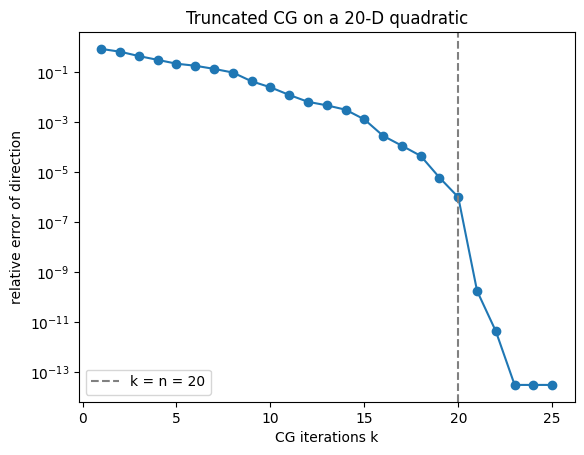

In [13]:
torch.manual_seed(0)
n = 20
Mrand = torch.randn(n, n, dtype=torch.float64)
A20 = Mrand @ Mrand.T / n + 0.1 * torch.eye(n, dtype=torch.float64)   # random symmetric positive definite matrix
b20 = torch.randn(n, dtype=torch.float64)
f20 = lambda w: 0.5 * w @ A20 @ w - b20 @ w

ev = torch.linalg.eigvalsh(A20)
print(f"eigenvalues: min = {ev.min().item():.4f}  max = {ev.max().item():.4f}  condition number = {(ev.max()/ev.min()).item():.1f}")

w = torch.randn(n, dtype=torch.float64, requires_grad=True)
g = torch.autograd.grad(f20(w), w, create_graph=True)[0].detach()
d_exact = -torch.linalg.solve(A20, g)                                  # the exact Newton direction
f0 = f20(w).item()                                                     # loss before the step
f_star = f20(w.detach() + d_exact).item()                              # loss after the exact Newton step (the minimum)

def cg_fixed(f, w, g, iters, tol=1e-12):
    # Same CG as before, but silent, with a hard cap on the iteration count.
    d = torch.zeros_like(g); r = -g.clone(); p = r.clone(); rs = r @ r
    for _ in range(iters):
        Hp = hvp(f, w, p)
        alpha = rs / (p @ Hp)
        d = d + alpha * p
        r = r - alpha * Hp
        rs_new = r @ r
        if rs_new.sqrt() < tol:                                        # already converged -> avoid 0/0
            break
        p = r + (rs_new / rs) * p
        rs = rs_new
    return d

def quality(k):
    d = cg_fixed(f20, w, g, k)
    rel_err = ((d - d_exact).norm() / d_exact.norm()).item()
    cosine  = (d @ d_exact / (d.norm() * d_exact.norm())).item()
    captured = (f0 - f20(w.detach() + d).item()) / (f0 - f_star)
    return rel_err, cosine, captured

print(f"f(w0) = {f0:.4f}   f(w after exact Newton step) = {f_star:.4f}\n")
print(f"{'k':>3}{'rel. direction error':>22}{'cosine':>10}{'loss decrease captured':>26}")
for k in (1, 2, 3, 5, 8, 10, 15, 20, 25):
    e, c, cap = quality(k)
    print(f"{k:3d}{e:22.3e}{c:10.5f}{cap:26.5f}")

# Plot the error against k for every k from 1 to 25.
ks = list(range(1, 26))
plt.semilogy(ks, [quality(k)[0] for k in ks], marker="o")
plt.axvline(n, color="grey", linestyle="--", label="k = n = 20")
plt.xlabel("CG iterations k")
plt.ylabel("relative error of direction")
plt.title("Truncated CG on a 20-D quadratic")
plt.legend()
plt.show()

**Result** (condition number ≈ 36.4, eigenvalues 0.10 – 3.67):

| k | relative direction error | cosine | loss decrease captured |
|---|---|---|---|
| 1 | 0.879 | 0.559 | 47.6% |
| 3 | 0.454 | 0.925 | 83.9% |
| 5 | 0.225 | 0.977 | 96.8% |
| 10 | 0.0254 | 0.9997 | 99.9% |
| 15 | 1.3e-3 | 1.0000 | 100.0% |
| 20 | 9.9e-7 | 1.0000 | 100.0% |
| 25 | 2.9e-14 | 1.0000 | 100.0% |

Quality improves steadily and the direction becomes essentially exact at **k = n = 20**, as CG theory promises for an n-dimensional quadratic (the error at k = 20 is ≈ 10⁻⁶, and ≈ 10⁻¹⁴ by k = 25, only round-off). The practical point: **5 iterations — a quarter of n — already capture 96.8% of the achievable loss decrease**, and 10 capture 99.9%, even though the *direction* error at k = 5 is still 22%. CG resolves the high-curvature directions first, and those dominate the loss, so a truncated Newton direction is nearly as good as the exact one at a fraction of the cost. That is why Hessian-free training stops CG after 5–20 iterations.

## Checkpoint

### Q1. What is the Hessian-vector product trick?
Hv = ∇(gᵀv): compute the gradient with `create_graph=True`, take its dot product with v (a scalar), and differentiate that scalar. It costs about one extra backward pass and never builds H, so memory is O(n).

### Q2. Why does `hvp` use `create_graph=True`?
The gradient must stay differentiable so that gᵀv can be differentiated a second time.

### Q3. How many CG iterations does an n-dimensional quadratic need?
At most n in exact arithmetic (Part 6: n = 2, residual collapses at iteration 2; Exercise 6: n = 20, error ≈ 10⁻⁶ at k = 20).

### Q4. Why stop CG early in real training?
An approximate Newton direction is good enough and far cheaper. Exercise 6: k = 5 of n = 20 already captured 96.8% of the achievable loss decrease.

### Q5. What memory does Hessian-free use vs Newton?
O(n) (a few vectors) vs O(n²).

# **Part 7 — Putting It Together**

Each method in this lab trades a different amount of curvature accuracy against cost per iteration.

| Method | Curvature used | Memory | Where it fits |
|---|---|---|---|
| Gradient descent | none | O(n) | Large DNNs |
| Newton | exact Hessian | O(n²) | Small models, teaching |
| Gauss–Newton / LM | JᵀJ approximation | O(n²) or less | Least-squares and curve fitting |
| L-BFGS | implicit, from m past gradients | O(mn) | Full-batch, medium problems |
| Hessian-free | implicit, via Hv products | O(n) | Deep research models |

Second-order methods win on **iteration count** in every task above, and lose on **cost per iteration** everywhere except the smallest problems. That is precisely why SGD, Momentum and Adam still dominate large-scale deep learning, while L-BFGS and Hessian-free methods survive in scientific machine learning, fine-tuning and full-batch problems where high accuracy matters more than throughput.

---

## Table 1 — Main Numbers from This Lab

| # | Experiment | Key measurement |
|---|---|---|
| 1 | Newton, L = w² − 4w + 5, w₀ = 5 | g = 6, H = 2, w₁ = 2 (loss 10 → 1) |
| 2 | Exercise 1: L = 3w² − 12w + 7, w₀ = 4 | g = 12, H = 6, w₁ = 2 (loss 7 → −5) |
| 3 | Exercise 3: quartic, w₀ = 0.1 | H = −5.88 → converged to local **maximum** at w = 0.1699 |
| 4 | GD, κ = 20, 60 iterations | error 1.7e-2 |
| 5 | Newton, κ = 20, 1 step | error 9.7e-8 |
| 6 | Exercise 2: GD iterations to reach 1e-7 | 188 (κ = 20) vs 4,279 (κ = 400) |
| 7 | Hessian memory, n = 769 → 3,073 | 2.26 → 36.02 MB (≈ 16×) |
| 8 | Extrapolated Hessian, n = 10⁷ | 364 TB |
| 9 | Gauss–Newton, SSE after 3 / 10 iters | 0.01275 / 0.01275 |
| 10 | LM λ = 1000, SSE after 10 iters | 18.62 (≈ gradient descent) |
| 11 | Adam: steps to reach SSE 0.01275 | 0.07337 at 50 steps; 0.01275 by 200 |
| 12 | L-BFGS steps to reach SSE 0.01275 | 1 |
| 13 | Exercise 5: mini-batch L-BFGS MSE, 5 → 100 epochs | 4.0e-4 → 9.5e-4 (worsens) |
| 14 | CG on the 2-D quadratic | 2 iterations to residual ≈ 3e-5; direction [−2.9, 5.0] |
| 15 | Exercise 6: loss decrease captured at k = 5 (n = 20) | 96.8% |

## Table 2 — Hand Calculations

| Check | Expected | Got | Match |
|---|---|---|---|
| L = w² − 4w + 5 at w = 5: g, H, w₁ | 6, 2, 2 | 6, 2, 2 | ✅ |
| L = 3w² − 12w + 7 at w = 4: g, H, w₁ | 12, 6, 2 | 12, 6, 2 | ✅ |
| Part 2: g at (3, −4) = A·w − b | [58, −5] | Newton step lands on [0.1, 1.0] | ✅ |
| Part 6: −H⁻¹g at (3, −4) | [−2.9, 5.0] | CG direction [−2.9, 5.0] | ✅ |
| Part 3: n² × 4 bytes at n = 10⁷ | ≈ 364 TB | 364 TB | ✅ |

## Table 3 — Conclusions

| Question | Answer |
|---|---|
| Which method gave the most progress per iteration? | Newton (one step on any quadratic, independent of κ), then Gauss–Newton (3 iterations) and L-BFGS (1 outer step). |
| Which method's cost blew up with size? | Full-Hessian Newton: O(n²) memory (364 TB at n = 10⁷) and O(n³) solve. |
| What did damping buy? | Safety: LM with λ raised after a failed step recovered from a start where near-undamped Gauss–Newton overshot to SSE ≈ 10²⁶ (Exercise 4, Run B). |
| Which optimizer is hurt by mini-batches? | L-BFGS — mini-batch MSE worsened with more epochs while Adam kept improving (Exercise 5). |
| How many CG iterations are enough? | 5–10 of n = 20 captured 96.8–99.9% of the achievable loss decrease (Exercise 6). |
| Notable observation | Newton is *not* a minimizer-finder — it finds stationary points. With H < 0 it converged to a maximum (Exercise 3). |

---

# Group 1 — Autograd and Derivatives

### Q1. Write the Newton update in one and n dimensions.
1-D: w ← w − L′(w)/L″(w). n-D: w ← w − H⁻¹g, computed by solving HΔw = −g.

### Q2. `autograd.grad` vs `.backward()` vs `hessian()`?
`autograd.grad` returns the gradient as a tensor without touching `.grad`. `.backward()` accumulates gradients into the parameters' `.grad`. `hessian()` returns the full n × n matrix of second derivatives.

### Q3. Why must the gradient be built with `create_graph=True` before differentiating again?
Otherwise the gradient is a constant with no graph, and there is nothing to differentiate.

### Q4. Cost of a Hessian-vector product vs a gradient?
A small constant multiple (about 2–3×) of one gradient evaluation, and O(n) memory — versus O(n²) memory for the full Hessian.

---

# Group 2 — Newton's Method

### Q1. When is Newton exact?
On a quadratic objective: the Taylor model is the function itself.

### Q2. Name three ways Newton can fail.
(1) H indefinite or negative → converges to a maximum or saddle (Exercise 3). (2) H singular → no solution to HΔw = −g. (3) Far from the optimum on non-quadratic losses → the local model is poor and the full step can overshoot.

### Q3. Per-iteration cost: Newton vs gradient descent?
Newton: O(n²) memory and O(n³) time for the solve. GD: O(n) for both.

### Q4. Convergence rate?
Newton converges quadratically near a minimum with H > 0; GD converges linearly at a rate set by κ.

---

# Group 3 — Gauss–Newton and Levenberg–Marquardt

### Q1. When is JᵀJ a good stand-in for H?
When the loss is a sum of squared residuals and residuals are small or the model is nearly linear, so the dropped term Σ rᵢ∇²rᵢ is small.

### Q2. Interpret λ.
Blend knob between Gauss–Newton (λ → 0) and gradient descent with lr = 1/λ (λ → ∞).

### Q3. Adaptive rule?
Success → λ/10; failure (SSE increased) → reject step, λ × 10.

### Q4. Cost per iteration?
Building J (n_residuals × n_params) and solving an n_params × n_params system. Cheap for curve fitting (2 parameters here), expensive for large networks.

---

# Group 4 — Quasi-Newton (L-BFGS)

### Q1. BFGS vs L-BFGS memory?
BFGS stores a dense n × n inverse-Hessian estimate: O(n²). L-BFGS keeps only the last m (parameter-change, gradient-change) pairs: O(mn).

### Q2. What condition do the pairs enforce?
The secant condition: the approximate Hessian maps the last parameter change s to the last gradient change y (H s = y).

### Q3. Why does PyTorch's L-BFGS take a closure and often use a line search?
Because it must re-evaluate the loss/gradient at trial points to choose a step length (`line_search_fn="strong_wolfe"` in Exercise 5).

### Q4. Main limitation?
Needs a deterministic loss; mini-batch noise breaks the curvature estimates.

---

# Group 5 — Hessian-Free Optimization

### Q1. Steps of one Hessian-free iteration?
Compute g → run CG on HΔw = −g using Hv products → update w ← w + Δw.

### Q2. What is "truncated Newton"?
Newton with the linear solve stopped early (a few CG iterations), giving an approximate direction.

### Q3. Why is it practical for deep nets?
Only Hessian-vector products are needed (about one extra backward pass each), and memory stays O(n).

### Q4. Is damping still needed?
In practice yes — real network Hessians are indefinite, so implementations add λI (as in LM) to keep CG well-posed.

---

# Group 6 — Choosing a Method

### Q1. 100M-parameter transformer, mini-batches?
SGD/Momentum/Adam — cost per iteration and stochastic gradients rule out second-order methods.

### Q2. Fitting 3 parameters to 10,000 noisy points?
Levenberg–Marquardt (least-squares, tiny system to solve).

### Q3. Full-batch logistic regression with 50,000 features?
L-BFGS — deterministic loss, and storing an n × n Hessian is out of the question.

### Q4. 5-parameter smooth problem where H is cheap?
Newton (exact Hessian, a handful of iterations).

### Q5. Very ill-conditioned full-batch problem on a big model?
Hessian-free (truncated CG with damping) — captures curvature without forming H.

### Q6. Why do second-order methods win on iterations but not always on wall-clock?
Each iteration costs more (Hessian, Jacobian, CG products, or line searches). In Exercise 5, L-BFGS needed 12,082 closure evaluations on mini-batches vs 500 for Adam.